In [ ]:
# # read from the csv file the calibration data for a given token

# import csv
# import numpy as np
# import ast

# def load_calib_from_csv(csv_file, query_token, cam_channel="CAM_FRONT"):
#     with open(csv_file, mode='r') as f:
#         reader = csv.DictReader(f)
#         for row in reader:
#             if row["sample_token"] == query_token and row["cam_channel"] == cam_channel:
#                 K = np.array(ast.literal_eval(row["K_flat"])).reshape(3, 3)
#                 R = np.array(ast.literal_eval(row["R_flat"])).reshape(3, 3)
#                 T = np.array(ast.literal_eval(row["T_flat"])).reshape(3,)
#                 lidar2img = np.array(ast.literal_eval(row["lidar2img_flat"])).reshape(3, 4)
#                 img_shape = (int(row["img_height"]), int(row["img_width"]))
#                 return {
#                     "K": K,
#                     "R": R,
#                     "T": T,
#                     "lidar2img": lidar2img,
#                     "img_shape": img_shape
#                 }
#     raise KeyError(f"Sample {query_token} with channel {cam_channel} not found in CSV.")


# csv_file = "calib_pseudo_test_front.csv"
# query_token = "5937faeeeb7d40b4903a441b0b95b204"  # Replace with your token

# calib = load_calib_from_csv(csv_file, query_token)
# print("Camera intrinsics K:\n", calib['K'])
# print("Camera rotation R:\n", calib['R'])
# print("Camera translation T:\n", calib['T'])
# print("LiDAR-to-image matrix:\n", calib['lidar2img'])
# print("Image shape:", calib['img_shape'])

# # for lidar sample 
# lidar2img_nusc = calib['lidar2img']
# img_shape_nusc = calib['img_shape']

# # for camera sample 
# K = calib['K']
# R = calib['R']
# T = calib['T']



Camera intrinsics K:
 [[1.25281310e+03 0.00000000e+00 8.26588115e+02]
 [0.00000000e+00 1.25281310e+03 4.69984663e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Camera rotation R:
 [[ 0.01026021  0.00843345  0.9999118 ]
 [-0.99987258  0.01231626  0.01015593]
 [-0.01222952 -0.99988859  0.00855874]]
Camera translation T:
 [1.72200568 0.00475453 1.49491292]
LiDAR-to-image matrix:
 [[ 1.24393696e+03  8.39164591e+02  3.48167664e+01 -5.66412107e+02]
 [-1.64608025e+01  5.38165195e+02 -1.22496266e+03 -7.58223752e+02]
 [-1.05896235e-02  9.98424173e-01  5.51092642e-02 -6.76849091e-01]]
Image shape: (900, 1600)


Lidar  visualization 

In [3]:




from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import numpy as np
import os
import matplotlib.pyplot as plt

# ===========================================================
# 1. Load dataset and choose your specific sample
# ===========================================================
dataroot = "/home/draiman/Desktop/datasets/nuscenes_pseudo_test"

nusc = NuScenes(version='v1.0-pseudo-test', dataroot=dataroot, verbose=False)

# sample = nusc.sample[0]   # your chosen keyframe
cam = 'CAM_FRONT'
# print("Processing sample token:", sample['token'])
# 5937faeeeb7d40b4903a441b0b95b204


for sample_ in nusc.sample:
    if sample_['token'] == '5937faeeeb7d40b4903a441b0b95b204':
        sample = sample_
        break
print("Found sample token:", sample['token'])
# ============================================

Found sample token: 5937faeeeb7d40b4903a441b0b95b204


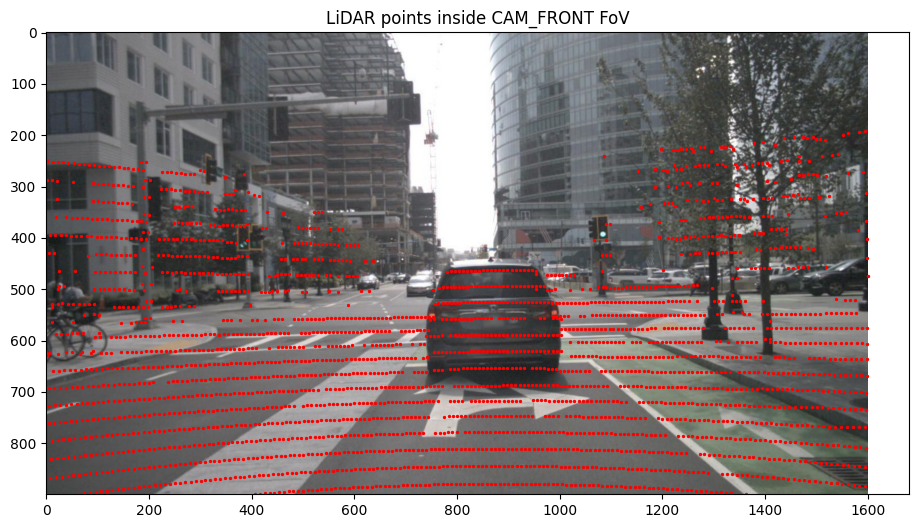

Total LiDAR points: 34720
Points inside CAM_FRONT FoV: 2692


In [ ]:

# 2. Get sample_data for camera and lidar
# ===========================================================
sd_cam  = nusc.get('sample_data', sample['data'][cam])
sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# Load calibration + poses
cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
cs_lid = nusc.get('calibrated_sensor', sd_lidar['calibrated_sensor_token'])

ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
ep_lid = nusc.get('ego_pose', sd_lidar['ego_pose_token'])


# ===========================================================
# 3. Load LiDAR point cloud in LIDAR_TOP frame
# ===========================================================
lidar_path = os.path.join(nusc.dataroot, sd_lidar['filename'])
pc = LidarPointCloud.from_file(lidar_path)   # shape = (4, N)


# ===========================================================
# 4. Transform LiDAR → CAM_FRONT coordinate system
# ===========================================================

# Step A: LIDAR_TOP → ego (at lidar time)
pc.rotate(Quaternion(cs_lid['rotation']).rotation_matrix)
pc.translate(cs_lid['translation'])

# ego (lidar time) → global
pc.rotate(Quaternion(ep_lid['rotation']).rotation_matrix)
pc.translate(ep_lid['translation'])

# global → ego (camera time)
pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# ego (camera time) → camera frame
pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

points_cam = pc.points  # now in camera coordinates (4,N)


# ===========================================================
# 5. PROJECT TO IMAGE
# ===========================================================
K = np.array(cs_cam['camera_intrinsic'])
pts_img = view_points(points_cam[:3, :], K, normalize=True)
u, v = pts_img[0, :], pts_img[1, :]
depth = points_cam[2, :]


# ===========================================================
# 6. BUILD BOOLEAN FOV MASK
# ===========================================================
w, h = sd_cam['width'], sd_cam['height']

mask_in_front = depth > 0
mask_u = (u >= 0) & (u < w)
mask_v = (v >= 0) & (v < h)

fov_mask = mask_in_front & mask_u & mask_v   # FINAL ANSWER


# ===========================================================
# 7. OPTIONAL: visualize
# ===========================================================
img_path = os.path.join(nusc.dataroot, sd_cam['filename'])
img = plt.imread(img_path)

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.scatter(u[fov_mask], v[fov_mask], s=2, c='red')
plt.title("LiDAR points inside CAM_FRONT FoV")
plt.show()

print(f"Total LiDAR points: {points_cam.shape[1]}")
print(f"Points inside CAM_FRONT FoV: {fov_mask.sum()}")


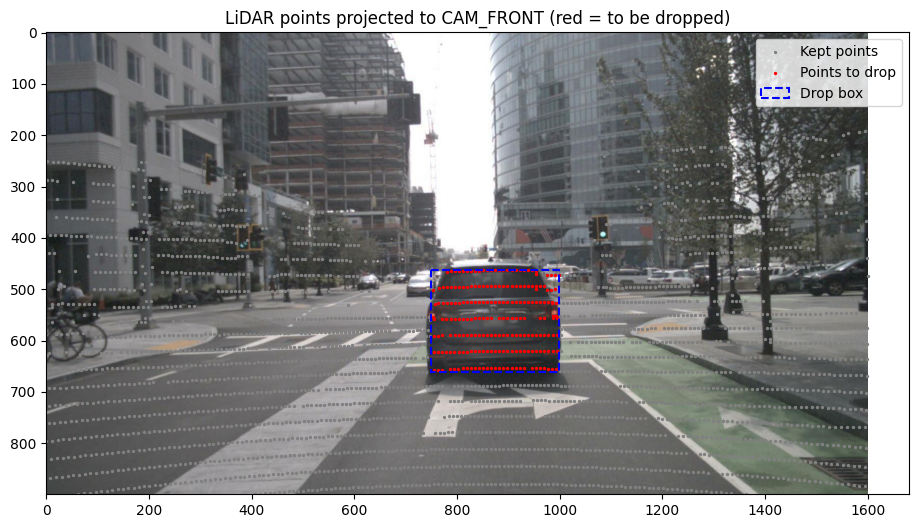

Total points projected into image: 2692
Points to be dropped (in box): 210
Points to keep (in image, not in box): 2482


In [11]:
# # ====== Drop Central Cluster of Projected Points (Rectangular Region) ======

# # 1. Define the rectangle for the cluster (tune as needed)
# center_u = w // 1.83        # image center u (horizontal)
# center_v = h // 1.6        # image center v (vertical)
# box_w   = 250            # width of cluster region (pixels)
# box_h   = 200            # height of cluster region (pixels)

# # 2. Compute boolean mask for points inside this region (in image plane)
# in_cluster = (
#     (u >= center_u - box_w//2) & (u < center_u + box_w//2) &
#     (v >= center_v - box_h//2) & (v < center_v + box_h//2)
# )

# # 3. Combine with original FoV mask: only keep points *not* in the cluster
# fov_mask_nocluster = fov_mask & (~in_cluster)

# # =========================
# # Visualize for feedback
# # =========================

# plt.figure(figsize=(12, 6))
# plt.imshow(img)
# plt.scatter(u[fov_mask], v[fov_mask], s=2, c='gray', label='All FoV')
# plt.scatter(u[fov_mask_nocluster], v[fov_mask_nocluster], s=2, c='red', label='FoV minus cluster')
# # Draw rectangle for reference
# rect = plt.Rectangle((center_u - box_w//2, center_v - box_h//2), box_w, box_h,
#                      linewidth=1.5, edgecolor='blue', facecolor='none', linestyle='--', label='Dropped cluster')
# plt.gca().add_patch(rect)a
# plt.legend(loc='upper right')
# plt.title("LiDAR points inside CAM_FRONT FoV (central cluster removed)")
# plt.show()

# print(f"Total FoV points: {fov_mask.sum()}")
# print(f"FoV points after cluster removal: {fov_mask_nocluster.sum()}")



# ====== Drop Central Cluster of Projected Points (Rectangular Region) - No FoV ======

# 1. Define the rectangle for the cluster (tune as needed)
center_u = w // 1.83        # image center u (horizontal)
center_v = h // 1.6         # image center v (vertical)
box_w   = 250               # width of cluster region (pixels)
box_h   = 200               # height of cluster region (pixels)

# 2. Compute boolean mask for points inside this region (in image plane)
# Also require points to be in front of camera
in_box = (
    (u >= center_u - box_w//2) & (u < center_u + box_w//2) &
    (v >= center_v - box_h//2) & (v < center_v + box_h//2) &
    (depth > 0)
)

# 3. Mask for points that actually appear in the image (for clean plotting)
in_image = (u >= 0) & (u < w) & (v >= 0) & (v < h) & (depth > 0)

# =========================
# Visualize for feedback
# =========================

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.scatter(u[in_image & ~in_box], v[in_image & ~in_box], s=2, c='gray', label='Kept points')
plt.scatter(u[in_box], v[in_box], s=2, c='red', label='Points to drop')
# Draw rectangle for reference
rect = plt.Rectangle((center_u - box_w//2, center_v - box_h//2), box_w, box_h,
                     linewidth=1.5, edgecolor='blue', facecolor='none', linestyle='--', label='Drop box')
plt.gca().add_patch(rect)
plt.legend(loc='upper right')
plt.title("LiDAR points projected to CAM_FRONT (red = to be dropped)")
plt.show()

print(f"Total points projected into image: {np.count_nonzero(in_image)}")
print(f"Points to be dropped (in box): {np.count_nonzero(in_box)}")
print(f"Points to keep (in image, not in box): {np.count_nonzero(in_image & ~in_box)}")


In [ ]:
import os

# Assume your original LiDAR point cloud (before camera transforms) is:
# pc.points     # shape (4, N)     (as from NuScenes LidarPointCloud)

# The 'in_box' mask is computed on ALL points (should be same length as N)

# Keep points NOT in the box:
mask_keep = ~in_box

# # Save as (N, 4) float32, transposed back if needed
filtered_points = pc.points.T[mask_keep]    # shape (N, 4)

# Add a 5th dummy column (e.g., all zeros)
N = filtered_points.shape[0]
filtered_points_5d = np.zeros((N, 5), dtype=np.float32)
filtered_points_5d[:, :4] = filtered_points


fname = sd_lidar["filename"]   # samples/LIDAR_TOP/xxx__LIDAR_TOP__xxxx.pcd.bin
base  = os.path.basename(fname)    # n008-2018-08-28-13-40-50-0400__LIDAR_TOP__1535478568897031.pcd.bin

# # remove .pcd.bin
# lidar_id = base.replace(".pcd.bin", "")

# print(lidar_id)

filtered_points_5d.tofile(f'initial_lidar_attack_test/attack_raw/{base}')


Original: (34720, 4)
Synthetic cluster: (50, 4)


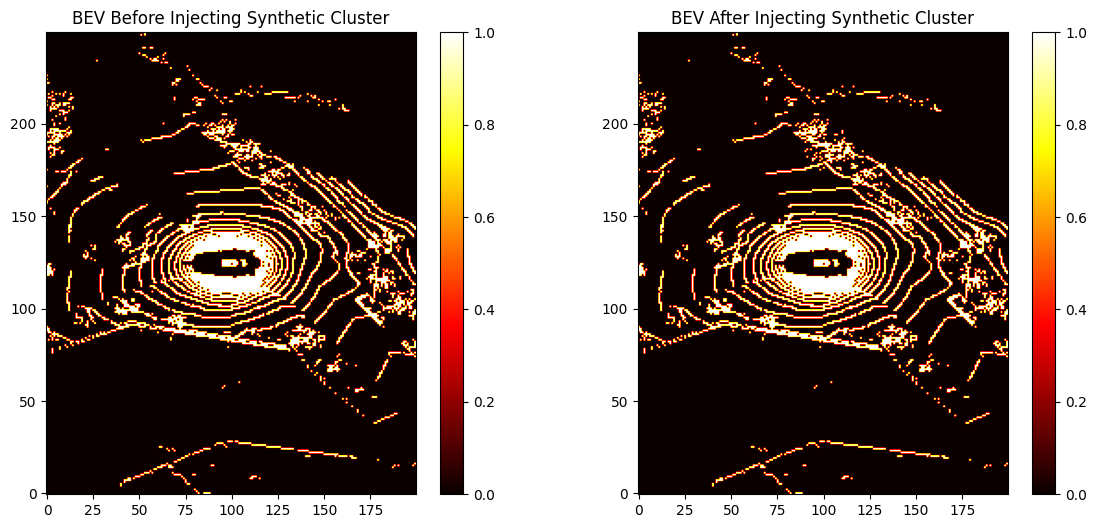

Original: (34720, 4)
Modified: (34510, 4)


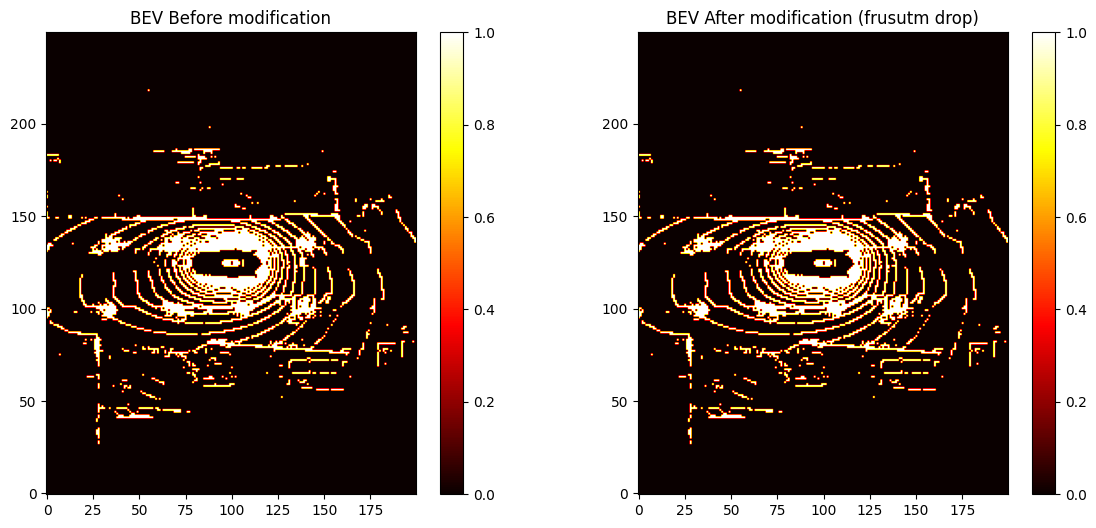

In [ ]:
# ---------------------------------------------------------
# 1. Load original LiDAR (same as before)
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

lidar_bin = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_res_testing/initial_lidar_attack_test/benign_raw/n008-2018-08-28-13-40-50-0400__LIDAR_TOP__1535478568897031.pcd.bin"
pts = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)[:, :4]  # x,y,z,intensity
print("Original:", pts.shape)

lidar_bin_ = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/final_res_testing/initial_lidar_attack_test/attack_raw/n008-2018-08-28-13-40-50-0400__LIDAR_TOP__1535478568897031.pcd.bin"
pts_mod = np.fromfile(lidar_bin_, dtype=np.float32).reshape(-1, 5)[:, :4]  # x,y,z,intensity
print("Modified:", pts_mod.shape)



# ---------------------------------------------------------
# 2. Define BEV spec (front 50m × 50m)
# ---------------------------------------------------------
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(
    x_min=-50.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)


# ---------------------------------------------------------
# 3. Build a function converting point cloud to BEV
# ---------------------------------------------------------
def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W

    bev_occ    = np.zeros((H, W), dtype=np.float32)

    for px, py in zip(ix, iy):
        bev_occ[px, py] = 1.0

    return bev_occ


# ---------------------------------------------------------
# 5. Convert to BEV maps (before + after)
# ---------------------------------------------------------
bev_before = lidar_to_bev(pts, bev_spec)
bev_after = lidar_to_bev(pts_mod, bev_spec)


# ---------------------------------------------------------
# 6. Plot: before vs after (geometric alignment test)
# ---------------------------------------------------------
plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
plt.imshow(bev_before, cmap="hot", origin="lower")
plt.title("BEV Before modification")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(bev_after, cmap="hot", origin="lower")
plt.title("BEV After modification (frusutm drop)")
plt.colorbar()

plt.show()


In [23]:
N = orig_points.shape[0]
drop_indices = np.where(fov_mask & in_cluster)[0]  # indices to drop, from original lidar
mask_keep = np.ones(N, dtype=bool)
mask_keep[drop_indices] = False
filtered_points = orig_points[mask_keep]


In [24]:
# (Do not subset points before projection!)
# points_lidar = (4, N) or orig_points = (N, 4)

# Project all N points to camera
pts_cam = ...         # (3, N)
u, v, depth = ...     # shape (N,)

# Build masks of shape (N,)
fov_mask = (depth > 0) & (u >= 0) & (u < w) & (v >= 0) & (v < h)
in_cluster = (u >= center_u - box_w//2) & (u < center_u + box_w//2) & \
             (v >= center_v - box_h//2) & (v < center_v + box_h//2)

drop_mask = fov_mask & in_cluster
keep_mask = ~drop_mask     # True = keep, False = drop

filtered_points = orig_points[keep_mask]


TypeError: cannot unpack non-iterable ellipsis object

In [25]:
points = np.fromfile('n008-2018-08-28-13-40-50-0400__LIDAR_TOP__1535478568897031.pcd.bin', dtype=np.float32)
print(points.shape)          # Example output: (173600,) if N=43400 and 4 fields

# Now reshape:
points = points.reshape(-1, 4)   # Try (N, 4)
print(points.shape)              # Will print (N, 4) if correct

# If you get a ValueError, try (N, 5):
try:
    points = points.reshape(-1, 5)
    print(points.shape)
except ValueError:
    print("Not compatible with (N, 5)")


(173600,)
(43400, 4)
(34720, 5)


Just trying to see the difference between old projection and new one 

In [4]:
from pathlib import Path
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import transform_matrix, view_points
from pyquaternion import Quaternion
from PIL import Image
import matplotlib.pyplot as plt

# ===========================================================
# 1. Load dataset and choose your specific sample
# ===========================================================
dataroot = "/home/draiman/Desktop/datasets/nuscenes_pseudo_test"

nusc = NuScenes(version='v1.0-pseudo-test', dataroot=dataroot, verbose=False)

# sample = nusc.sample[0]   # your chosen keyframe
cam = 'CAM_FRONT'
# print("Processing sample token:", sample['token'])
# 5937faeeeb7d40b4903a441b0b95b204


for sample_ in nusc.sample:
    if sample_['token'] == '5937faeeeb7d40b4903a441b0b95b204':
        sample = sample_
        break
print("Found sample token:", sample['token'])
# ============================================


Found sample token: 5937faeeeb7d40b4903a441b0b95b204


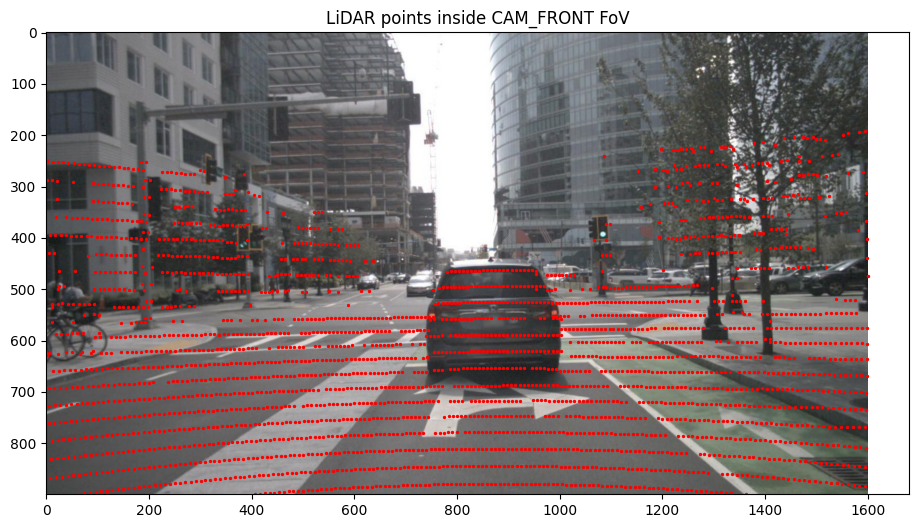

Total LiDAR points: 34720
Points inside CAM_FRONT FoV: 2692


In [5]:

# 2. Get sample_data for camera and lidar
# ===========================================================
sd_cam  = nusc.get('sample_data', sample['data'][cam])
sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# Load calibration + poses
cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
cs_lid = nusc.get('calibrated_sensor', sd_lidar['calibrated_sensor_token'])

ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
ep_lid = nusc.get('ego_pose', sd_lidar['ego_pose_token'])


# ===========================================================
# 3. Load LiDAR point cloud in LIDAR_TOP frame
# ===========================================================
lidar_path = os.path.join(nusc.dataroot, sd_lidar['filename'])
pc = LidarPointCloud.from_file(lidar_path)   # shape = (4, N)


# ===========================================================
# 4. Transform LiDAR → CAM_FRONT coordinate system
# ===========================================================

# Step A: LIDAR_TOP → ego (at lidar time)
pc.rotate(Quaternion(cs_lid['rotation']).rotation_matrix)
pc.translate(cs_lid['translation'])

# ego (lidar time) → global
pc.rotate(Quaternion(ep_lid['rotation']).rotation_matrix)
pc.translate(ep_lid['translation'])

# global → ego (camera time)
pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# ego (camera time) → camera frame
pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

points_cam = pc.points  # now in camera coordinates (4,N)


# ===========================================================
# 5. PROJECT TO IMAGE
# ===========================================================
K = np.array(cs_cam['camera_intrinsic'])
pts_img = view_points(points_cam[:3, :], K, normalize=True)
u, v = pts_img[0, :], pts_img[1, :]
depth = points_cam[2, :]


# ===========================================================
# 6. BUILD BOOLEAN FOV MASK
# ===========================================================
w, h = sd_cam['width'], sd_cam['height']

mask_in_front = depth > 0
mask_u = (u >= 0) & (u < w)
mask_v = (v >= 0) & (v < h)

fov_mask = mask_in_front & mask_u & mask_v   # FINAL ANSWER


# ===========================================================
# 7. OPTIONAL: visualize
# ===========================================================
img_path = os.path.join(nusc.dataroot, sd_cam['filename'])
img = plt.imread(img_path)

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.scatter(u[fov_mask], v[fov_mask], s=2, c='red')
plt.title("LiDAR points inside CAM_FRONT FoV")
plt.show()

print(f"Total LiDAR points: {points_cam.shape[1]}")
print(f"Points inside CAM_FRONT FoV: {fov_mask.sum()}")


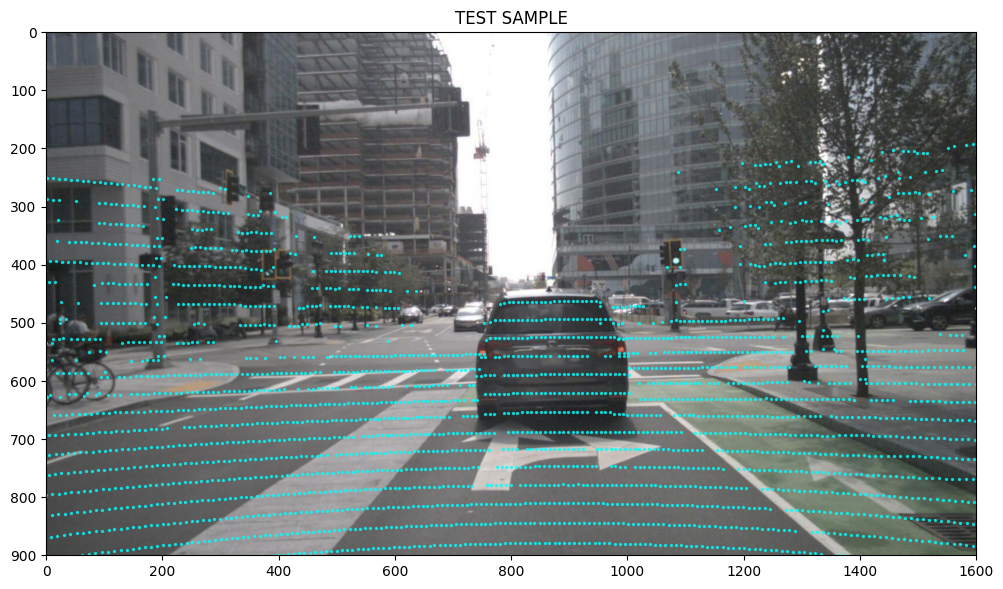

In [9]:


# 2. Get sample_data for camera and lidar
# ===========================================================
sd_cam  = nusc.get('sample_data', sample['data'][cam])
sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# Load calibration + poses
cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
cs_lid = nusc.get('calibrated_sensor', sd_lidar['calibrated_sensor_token'])

ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
ep_lid = nusc.get('ego_pose', sd_lidar['ego_pose_token'])


# ===========================================================
# 3. Load LiDAR point cloud in LIDAR_TOP frame
# ===========================================================
lidar_path = os.path.join(nusc.dataroot, sd_lidar['filename'])
pc = LidarPointCloud.from_file(lidar_path)   # shape = (4, N)
img_path = os.path.join(nusc.dataroot, sd_cam['filename'])
img = plt.imread(img_path)



# ----------------------
# LOAD LIDAR
# ----------------------
# Load LiDAR using nuScenes official API (same as Code 1)
pc = LidarPointCloud.from_file(lidar_path)   # (4, N)

# Extract coordinates the same way as Code 1
pts_xyz = pc.points[:3, :]   # (3, N)
pts_h = np.vstack((pts_xyz, np.ones((1, pts_xyz.shape[1]))))  # (4, N)

# ----------------------
# PROJECT LIDAR TO CAMERA
# ----------------------
calib_cam = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])
ego_cam   = nusc.get("ego_pose", sd_cam["ego_pose_token"])
sample_token = sample['token']
sample = nusc.get("sample", sample_token)
lid_sd_token = sample["data"]["LIDAR_TOP"]
lid_sd = nusc.get("sample_data", lid_sd_token)
calib_lid = nusc.get("calibrated_sensor", lid_sd["calibrated_sensor_token"])
ego_lid   = nusc.get("ego_pose", lid_sd["ego_pose_token"])



# Lidar->ego_lid
T_lid_ego = transform_matrix(calib_lid['translation'], Quaternion(calib_lid['rotation']))
pts_ego = T_lid_ego @ pts_h

# ego_lid->global
T_ego_glob = transform_matrix(ego_lid['translation'], Quaternion(ego_lid['rotation']))
pts_glob = T_ego_glob @ pts_ego

# global->ego_cam
T_ego_cam = transform_matrix(ego_cam['translation'], Quaternion(ego_cam['rotation']))
T_glob_ego_cam = np.linalg.inv(T_ego_cam)
pts_ego_cam = T_glob_ego_cam @ pts_glob

# ego_cam->camera
T_cam_ego = transform_matrix(calib_cam['translation'], Quaternion(calib_cam['rotation']))
T_ego_cam2 = np.linalg.inv(T_cam_ego)
pts_cam = T_ego_cam2 @ pts_ego_cam
pts_cam3 = pts_cam[:3, :]

# project
intrinsic = np.array(calib_cam["camera_intrinsic"])
uv = view_points(pts_cam3, intrinsic, normalize=True)
u, v = uv[0, :], uv[1, :]
z = pts_cam3[2, :]


# ----------------------
# LOAD IMAGE
# ----------------------
img = np.array(Image.open(img_path))
H, W = img.shape[:2]

# ----------------------
# VISUALIZATION
# ----------------------
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
plt.title(f"TEST SAMPLE")
plt.xlim(0, W)
plt.ylim(H, 0)
plt.show()


In [ ]:
# from nuscenes.nuscenes import NuScenes

# nusc = NuScenes(
#     version='v1.0-trainval',   # or your version e.g. v1.0-mini, v1.0-pseudo-test
#     dataroot='/home/draiman/Desktop/datasets/nuscenes'
# )

# print("Number of scenes:", len(nusc.scene))


Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 33.455 seconds.
Reverse indexing ...
Done reverse indexing in 6.6 seconds.
Number of scenes: 850
